In [40]:
!pip install pandas matplotlib seaborn lxml

In [41]:
%pip install nba_api

Note: you may need to restart the kernel to use updated packages.


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from nba_api.stats.endpoints import leaguedashplayerstats

In [43]:
sns.set_theme(style="whitegrid")

In [44]:
print("Fetching data from NBA API...")

# Fetches player statistics for the 2023-24 season via NBA API
api_call = leaguedashplayerstats.LeagueDashPlayerStats(
    season='2025-26',
    season_type_all_star='Regular Season'
)

Fetching data from NBA API...


In [45]:
# Converts API response directly to a Pandas DataFrame
df_raw = api_call.get_data_frames()[0]
print(f"Successfully fetched raw dataset: {df_raw.shape[0]} players.")

Successfully fetched raw dataset: 582 players.


In [46]:
# Selects relevant metrics for MVP analysis
cols_to_keep = [
    'PLAYER_NAME', 'TEAM_ABBREVIATION', 'GP', 'MIN', 
    'PTS', 'REB', 'AST', 'STL', 'BLK', 'FG_PCT', 'PLUS_MINUS'
]
df_clean = df_raw[cols_to_keep].copy()

In [47]:
# Filters for qualified players (at least 65 games played) to align with NBA minimum guidelines
df_clean = df_clean[df_clean['GP'] >= 65].reset_index(drop=True)

In [48]:
# Features Engineering: Calculates per-game statistics
df_clean['PTS_PG'] = round(df_clean['PTS'] / df_clean['GP'], 1)
df_clean['REB_PG'] = round(df_clean['REB'] / df_clean['GP'], 1)
df_clean['AST_PG'] = round(df_clean['AST'] / df_clean['GP'], 1)

In [49]:
df_clean.fillna(0, inplace=True)

,PLAYER_NAME,TEAM_ABBREVIATION,GP,MIN,PTS,REB,AST,STL,BLK,FG_PCT,PLUS_MINUS,PTS_PG,REB_PG,AST_PG
0,AJ Green,MIL,78,2269.933333,809,213,152,39,8,0.424,-148,10.4,2.7,1.9
1,Aaron Wiggins,OKC,65,1413.980000,611,199,109,60,28,0.431,178,9.4,3.1,1.7
2,Ace Bailey,UTA,72,1987.643333,993,302,131,60,49,0.443,-448,13.8,4.2,1.8
3,Adem Bona,PHI,71,1234.161667,344,307,32,30,82,0.595,-8,4.8,4.3,0.5
4,Alperen Sengun,HOU,72,2397.695000,1466,640,445,85,77,0.519,205,20.4,8.9,6.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,Wendell Carter Jr.,ORL,78,2288.351667,922,577,154,60,49,0.512,90,11.8,7.4,2.0
175,Will Richard,GSW,69,1376.805000,441,172,93,80,9,0.468,-97,6.4,2.5,1.3
176,Will Riley,WAS,74,1632.471667,764,212,146,54,9,0.439,-484,10.3,2.9,2.0
177,Yves Missi,NOP,66,1297.036667,377,385,84,20,101,0.544,-41,5.7,5.8,1.3


In [50]:
print(f"Cleaned dataset shape after filtering: {df_clean.shape}")
print(df_clean[['PLAYER_NAME', 'TEAM_ABBREVIATION', 'GP', 'PTS_PG', 'PLUS_MINUS']].head())

Cleaned dataset shape after filtering: (179, 14)
      PLAYER_NAME TEAM_ABBREVIATION  GP  PTS_PG  PLUS_MINUS
0        AJ Green               MIL  78    10.4        -148
1   Aaron Wiggins               OKC  65     9.4         178
2      Ace Bailey               UTA  72    13.8        -448
3       Adem Bona               PHI  71     4.8          -8
4  Alperen Sengun               HOU  72    20.4         205


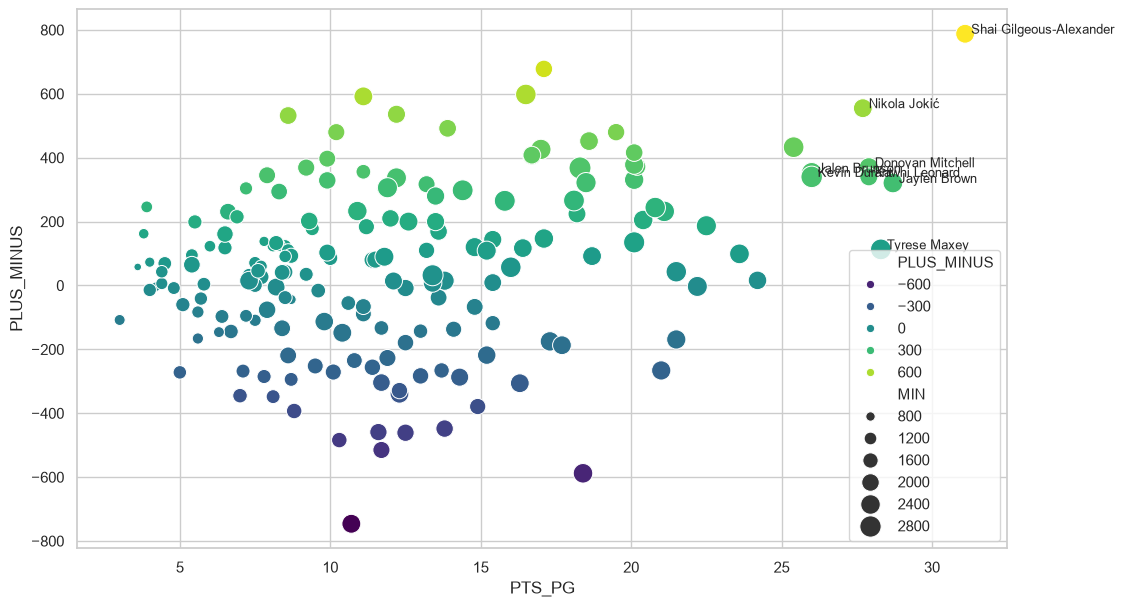

In [51]:
fig, ax = plt.subplots(figsize=(12, 7))

scatter = sns.scatterplot(
    data=df_clean,
    x='PTS_PG',
    y='PLUS_MINUS',
    size='MIN',
    hue='PLUS_MINUS',
    palette='viridis',
    sizes=(30, 250),
    ax=ax
)

# Annotate key top MVP candidates (scoring leaders with high +/-)
top_players = df_clean[df_clean['PTS_PG'] >= 26]
for idx, row in top_players.iterrows():
    ax.text(
        row['PTS_PG'] + 0.2, 
        row['PLUS_MINUS'], 
        row['PLAYER_NAME'], 
        fontsize=9,
        fontweight='medium'
    )

In [52]:
top_10_scorers = df_clean.sort_values(by='PTS_PG', ascending=False).head(10)

C:\Users\rames\AppData\Local\Temp\ipykernel_16736\518498226.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


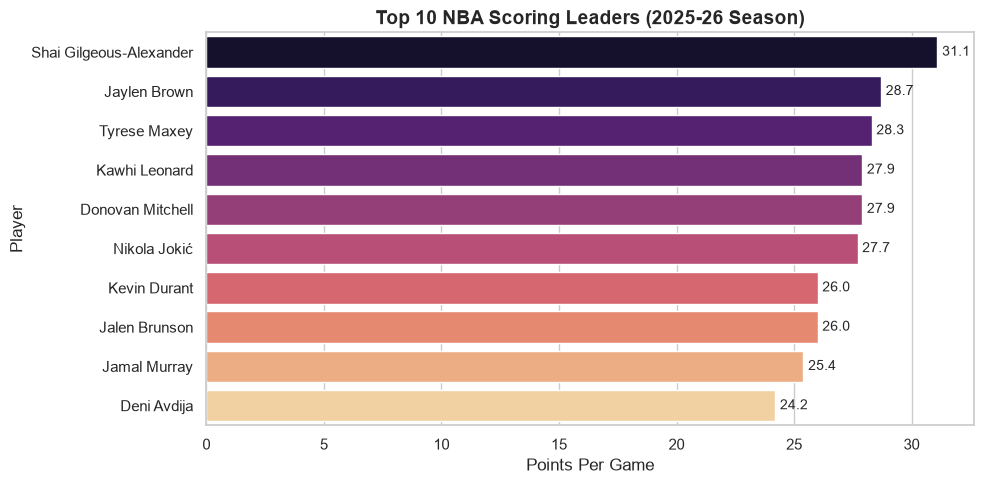

In [53]:
plt.figure(figsize=(10, 5))
barplot = sns.barplot(
    data=top_10_scorers,
    x='PTS_PG',
    y='PLAYER_NAME',
    palette='magma'
)

plt.title('Top 10 NBA Scoring Leaders (2025-26 Season)', fontsize=14, fontweight='bold')
plt.xlabel('Points Per Game', fontsize=12)
plt.ylabel('Player', fontsize=12)

# Adds numeric value labels on each bar
for index, value in enumerate(top_10_scorers['PTS_PG']):
    plt.text(value + 0.2, index, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()


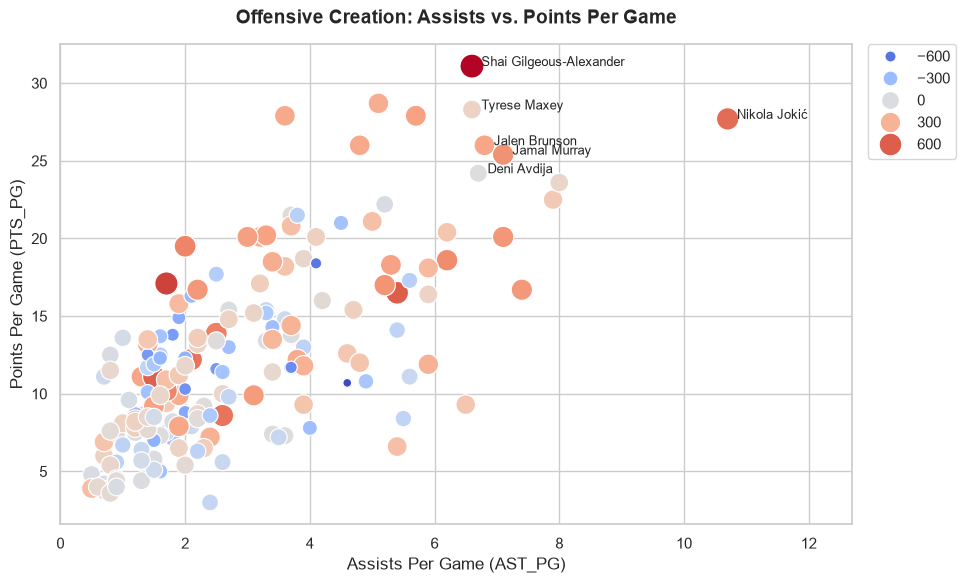

In [54]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.scatterplot(
    data=df_clean,
    x='AST_PG',
    y='PTS_PG',
    size='PLUS_MINUS',
    hue='PLUS_MINUS',
    palette='coolwarm',
    sizes=(40, 300),
    ax=ax
)

# Labels top playmakers/scorers
top_creators = df_clean[(df_clean['PTS_PG'] >= 24) & (df_clean['AST_PG'] >= 6)]
for idx, row in top_creators.iterrows():
    ax.text(row['AST_PG'] + 0.15, row['PTS_PG'], row['PLAYER_NAME'], fontsize=9)

ax.set_xlim(df_clean['AST_PG'].min() - 0.5, df_clean['AST_PG'].max() + 2)
plt.title('Offensive Creation: Assists vs. Points Per Game', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Assists Per Game (AST_PG)', fontsize=12)
plt.ylabel('Points Per Game (PTS_PG)', fontsize=12)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.subplots_adjust(left=0.08, right=0.80, top=0.90, bottom=0.10)
plt.show()

In [55]:
import os
os.makedirs('../visualisations', exist_ok=True)
os.makedirs('../data', exist_ok=True)

# Save cleaned dataset
df_clean.to_csv('../data/df_clean.csv', index=False)

# Re-save your figures as PNGs for HTML embedding
fig.savefig('../visualisations/heatmap.png', dpi=300, bbox_inches='tight')